## Loan Prediction Based on Customer Behavior
 - Probelm: Classification
 - Datasource: https://www.kaggle.com/datasets/subhamjain/loan-prediction-based-on-customer-behavior/data

### Load the basic library

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

pd.set_option('display.width', None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 50)

### Load the dataset

In [10]:
data = pd.read_csv('../data/raw/Training Data.csv')

### Get the insight on dataset

In [12]:
data.drop(columns=['Id'], inplace=True)

### Get the stats on the dataset

In [8]:
data.describe()

,Id,Income,Age,Experience,CURRENT_JOB_YRS,CURRENT_HOUSE_YRS,Risk_Flag
count,252000.000000,2.520000e+05,252000.000000,252000.000000,252000.000000,252000.000000,252000.000000
mean,126000.500000,4.997117e+06,49.954071,10.084437,6.333877,11.997794,0.123000
std,72746.278255,2.878311e+06,17.063855,6.002590,3.647053,1.399037,0.328438
min,1.000000,1.031000e+04,21.000000,0.000000,0.000000,10.000000,0.000000
25%,63000.750000,2.503015e+06,35.000000,5.000000,3.000000,11.000000,0.000000
50%,126000.500000,5.000694e+06,50.000000,10.000000,6.000000,12.000000,0.000000
75%,189000.250000,7.477502e+06,65.000000,15.000000,9.000000,13.000000,0.000000
max,252000.000000,9.999938e+06,79.000000,20.000000,14.000000,14.000000,1.000000


### Check the duplicates

In [9]:
data.duplicated().sum()

np.int64(0)

### Check for missing values

In [10]:
data.isnull().sum().sum()

np.int64(0)

### Get Categorical and Numeric columns

In [11]:
numeric_cols = data.select_dtypes(include=[np.number]).columns
categorical_cols = data.select_dtypes(include=[object]).columns

### Check Outlier

In [12]:
outlier_report = {}

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    outlier_count = len(outliers)

    outlier_percentage = (outlier_count / len(data)) * 100

    outlier_report[col] = {
        "Outlier Count": outlier_count,
        "Outlier Percentage": outlier_percentage
    }

pd.DataFrame(outlier_report).T.reset_index().rename(columns={"index": "Column"})

,Column,Outlier Count,Outlier Percentage
0,Id,0.0,0.0
1,Income,0.0,0.0
2,Age,0.0,0.0
3,Experience,0.0,0.0
4,CURRENT_JOB_YRS,0.0,0.0
5,CURRENT_HOUSE_YRS,0.0,0.0
6,Risk_Flag,30996.0,12.3


### Skewness analysis

In [13]:
skewness_report = {}

for col in numeric_cols:
    mean_val = data[col].mean()
    median_val = data[col].median()
    std_val = data[col].std()

    # Pearson's second skewness coefficient: 3 * (mean - median) / std
    if std_val == 0 or pd.isna(std_val):
        diff_val = 0
    else:
        diff_val = round(3 * (mean_val - median_val) / std_val, 2)

    if abs(diff_val) > 0.3:
        skew_due_to_outlier = "Likely Outlier-Driven"
    else:
        skew_due_to_outlier = "Unlikely Outlier-Driven"

    skew = data[col].skew()

    if skew > 0:
        direction = "Positively Skewed"
    elif skew < 0:
        direction = "Negatively Skewed"
    else:
        direction = "Roughly Symmetric"

    if abs(skew) < 0.5:
        skew_interpretation = "Fairly Symmetric - No transformation needed"
    elif abs(skew) < 1:
        skew_interpretation = "Moderately Skewed - Consider transformation if critical"
    else:
        skew_interpretation = "Highly Skewed - Transformation Recommended (log/sqrt/BoxCox)"

    skewness_report[col] = {
        "Skewness": round(skew, 2),
        "Pearson Skew": diff_val,
        "Skew Direction": direction,
        "Skew Interpretation": skew_interpretation,
        "Outlier Influence": skew_due_to_outlier,
    }

pd.DataFrame(skewness_report).T.reset_index().rename(columns={"index": "Column"})


,Column,Skewness,Pearson Skew,Skew Direction,Skew Interpretation,Outlier Influence
0,Id,0.0,0.0,Roughly Symmetric,Fairly Symmetric - No transformation needed,Unlikely Outlier-Driven
1,Income,0.01,-0.0,Positively Skewed,Fairly Symmetric - No transformation needed,Unlikely Outlier-Driven
2,Age,-0.01,-0.01,Negatively Skewed,Fairly Symmetric - No transformation needed,Unlikely Outlier-Driven
3,Experience,-0.01,0.04,Negatively Skewed,Fairly Symmetric - No transformation needed,Unlikely Outlier-Driven
4,CURRENT_JOB_YRS,0.27,0.27,Positively Skewed,Fairly Symmetric - No transformation needed,Unlikely Outlier-Driven
5,CURRENT_HOUSE_YRS,0.01,-0.0,Positively Skewed,Fairly Symmetric - No transformation needed,Unlikely Outlier-Driven
6,Risk_Flag,2.3,1.12,Positively Skewed,Highly Skewed - Transformation Recommended (lo...,Likely Outlier-Driven


### Correlation

<Axes: >

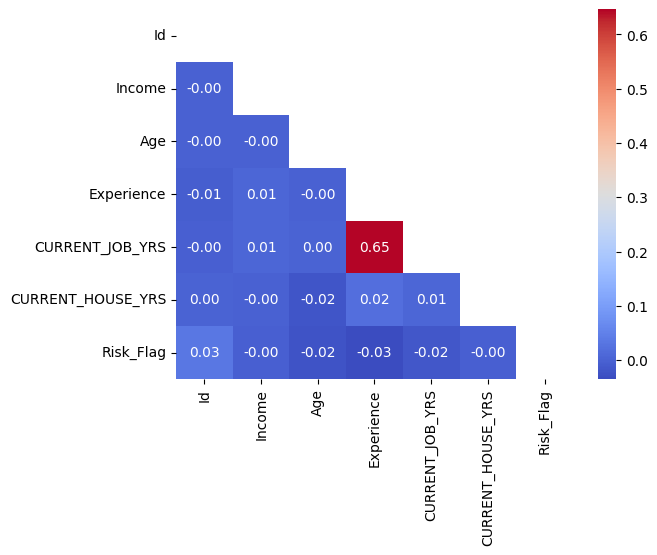

In [14]:
corr = data.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=np.triu(corr ))

### Multi-collinearity

In [15]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = data.drop(columns=['Risk_Flag']).select_dtypes(include=[np.number])
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data.sort_values(by="VIF", ascending=False)

vif_data

,Feature,VIF
0,Id,3.871777
1,Income,3.883039
2,Age,8.586788
3,Experience,6.542032
4,CURRENT_JOB_YRS,6.833131
5,CURRENT_HOUSE_YRS,15.299975


### Data insight on categorical columns

In [16]:
for col in categorical_cols:
    print(f"******** Col: {col}, unique Value: {data[col].nunique()}********")
    print(data[col].unique())
    print()

******** Col: Married/Single, unique Value: 2********
['single' 'married']

******** Col: House_Ownership, unique Value: 3********
['rented' 'norent_noown' 'owned']

******** Col: Car_Ownership, unique Value: 2********
['no' 'yes']

******** Col: Profession, unique Value: 51********
['Mechanical_engineer' 'Software_Developer' 'Technical_writer'
 'Civil_servant' 'Librarian' 'Economist' 'Flight_attendant' 'Architect'
 'Designer' 'Physician' 'Financial_Analyst' 'Air_traffic_controller'
 'Politician' 'Police_officer' 'Artist' 'Surveyor' 'Design_Engineer'
 'Chemical_engineer' 'Hotel_Manager' 'Dentist' 'Comedian'
 'Biomedical_Engineer' 'Graphic_Designer' 'Computer_hardware_engineer'
 'Petroleum_Engineer' 'Secretary' 'Computer_operator'
 'Chartered_Accountant' 'Technician' 'Microbiologist' 'Fashion_Designer'
 'Aviator' 'Psychologist' 'Magistrate' 'Lawyer' 'Firefighter' 'Engineer'
 'Official' 'Analyst' 'Geologist' 'Drafter' 'Statistician' 'Web_designer'
 'Consultant' 'Chef' 'Army_officer' 'Sur

### Data Distribution visualization

#### Univarient Analysis

##### Categorical distribution

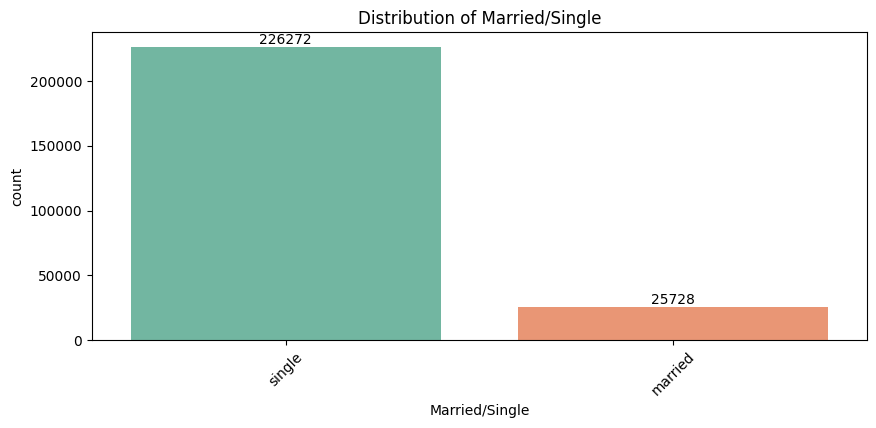

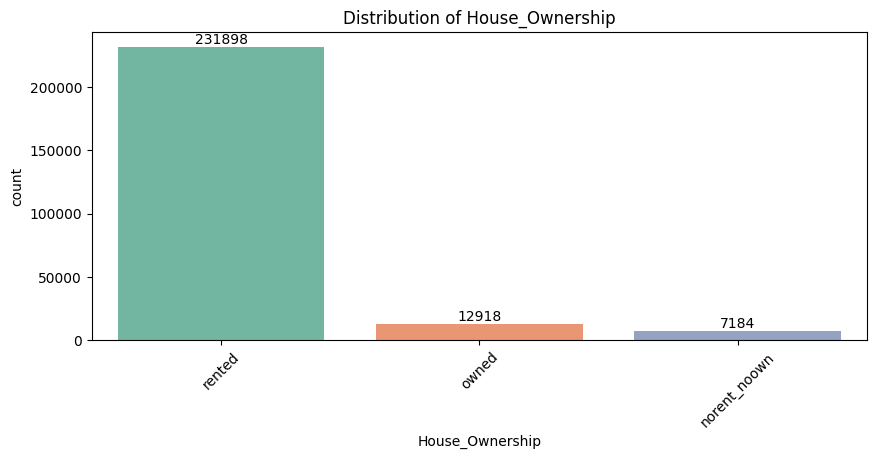

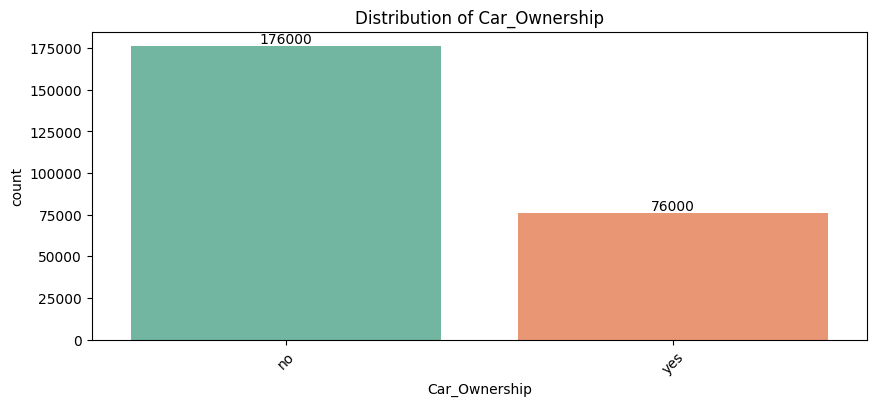

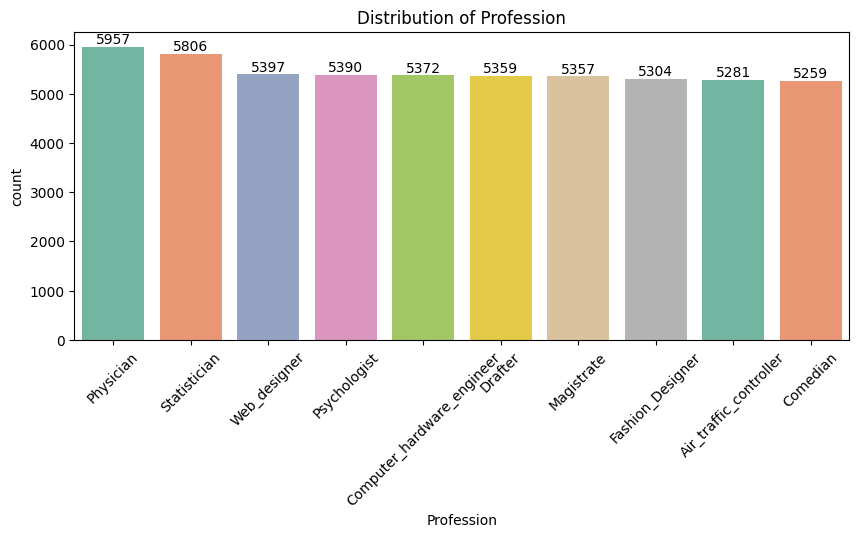

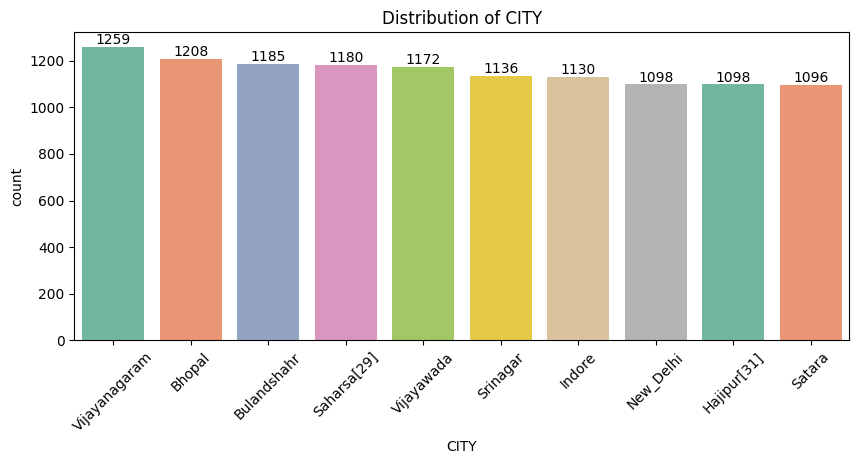

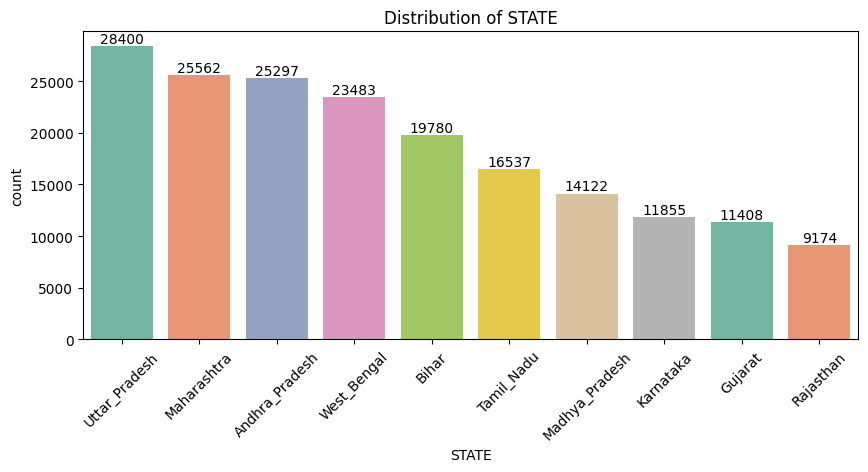

In [17]:
for col in categorical_cols:
    plt.figure(figsize=(10, 4))
    top_10 = data[col].value_counts().nlargest(10).index
    
    ax = sns.countplot(data=data, x=col, order=top_10, palette='Set2', legend=True)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    
    for i, container in enumerate(ax.containers):
        ax.bar_label(container)

    plt.show()

##### Numeric columns

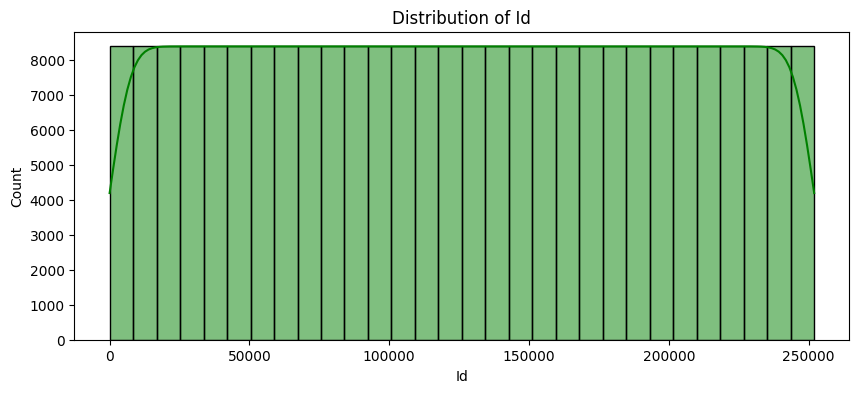

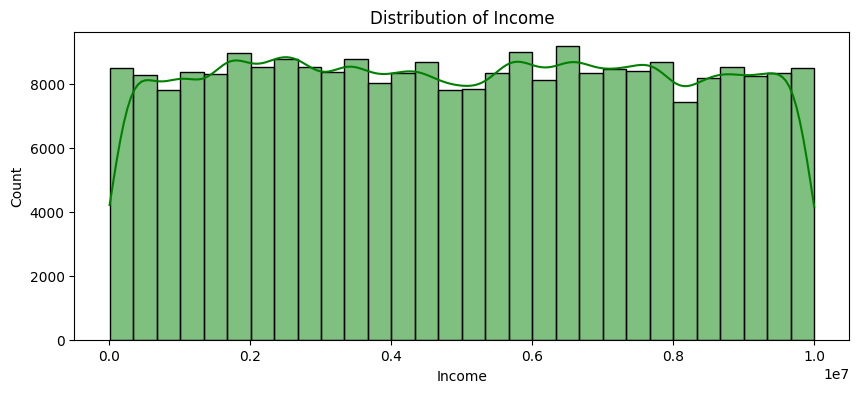

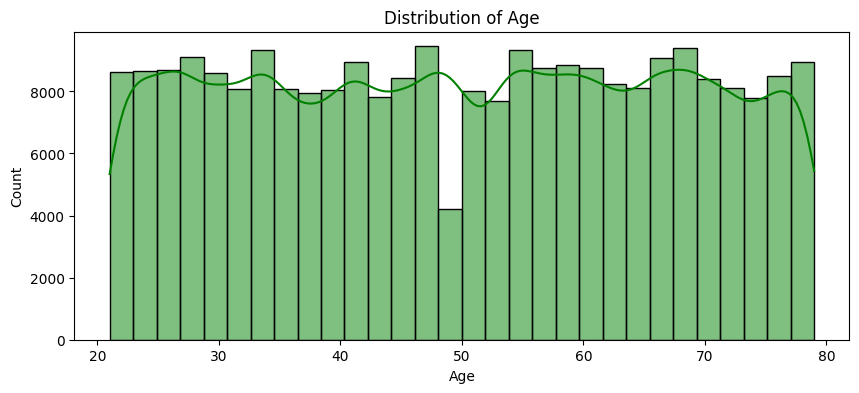

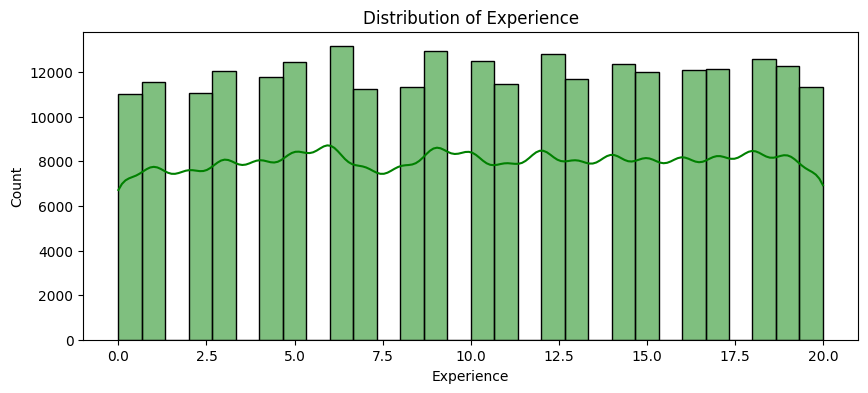

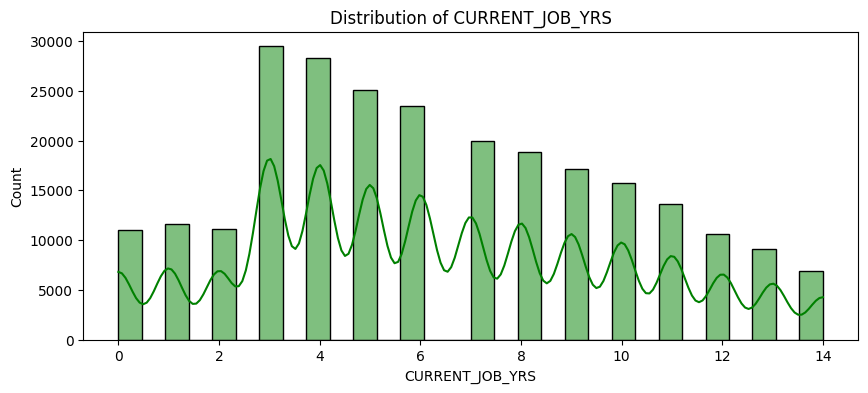

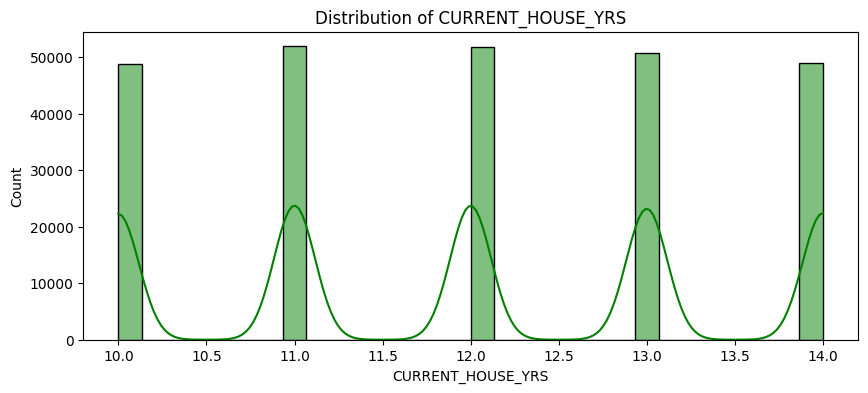

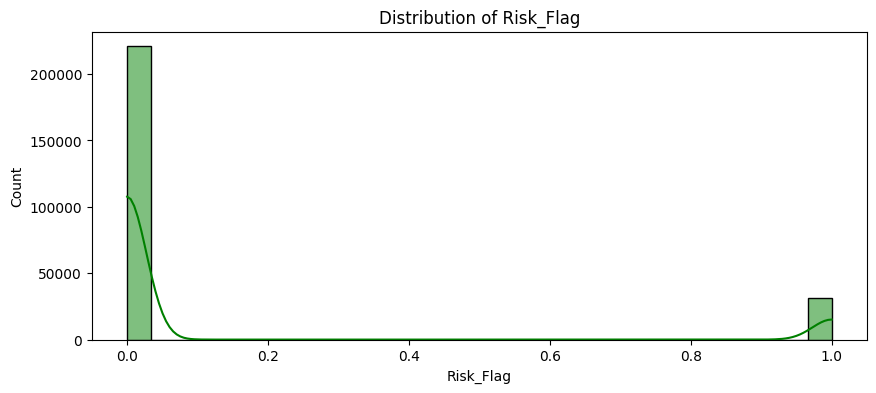

In [18]:
for col in numeric_cols:
    plt.figure(figsize=(10, 4))

    ax = sns.histplot(data[col].dropna(), kde=True, color='green', bins=30)
    plt.title(f"Distribution of {col}")


#### Bivarient Analysis

##### Numeric V/s Categorical

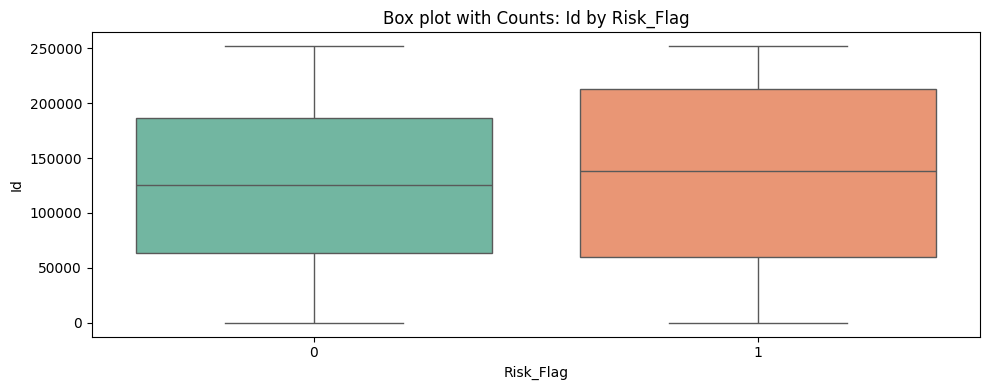

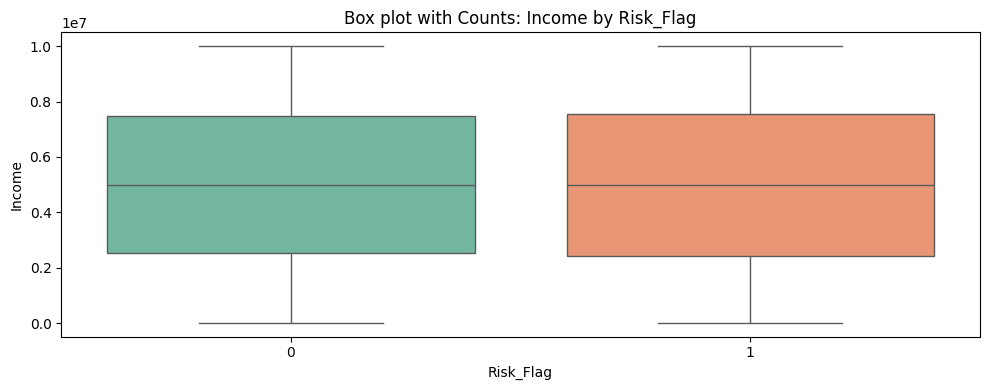

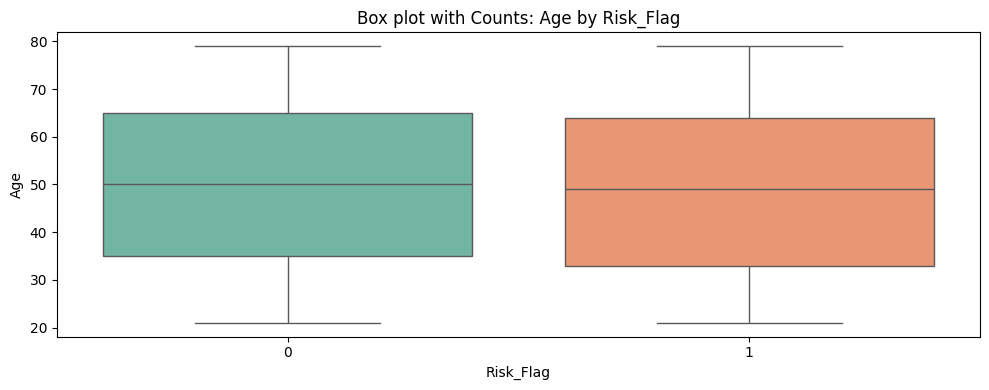

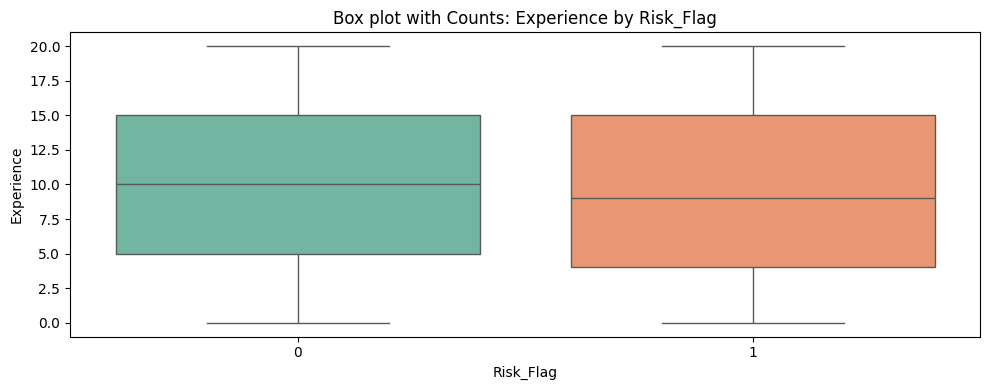

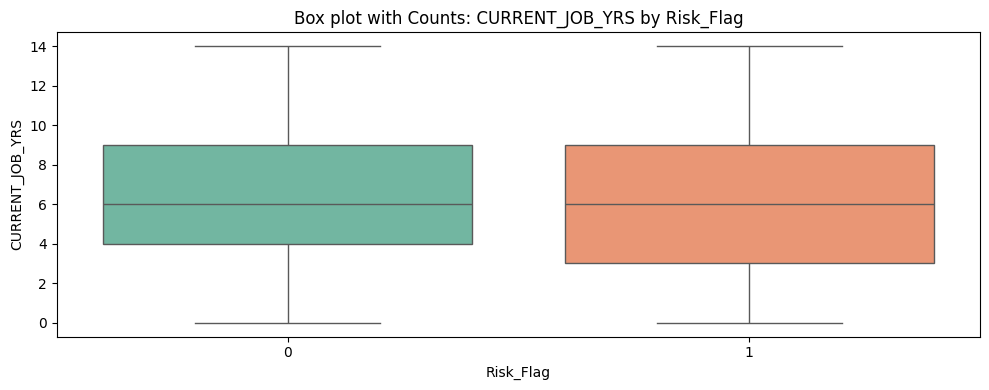

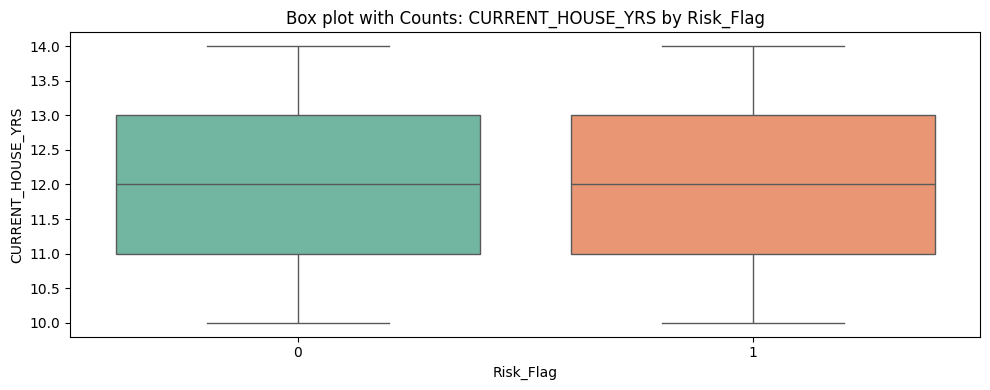

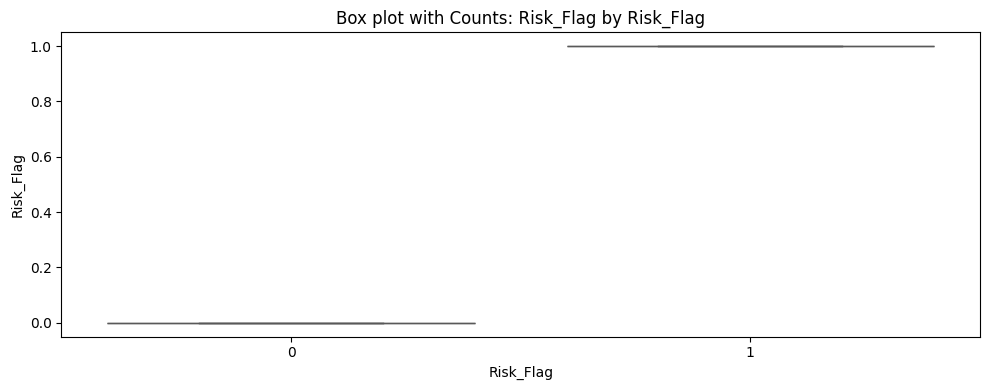

In [19]:
num_cols = data.select_dtypes(include=['number']).columns

for col in num_cols:
    plt.figure(figsize=(10, 4))

    sns.boxplot(data=data, x='Risk_Flag', y=col, hue='Risk_Flag', palette='Set2', legend=False)

    # Add count labels on top of each bin
    for container in ax.containers:
        ax.bar_label(container, fmt="%d")

    plt.title(f"Box plot with Counts: {col} by Risk_Flag")
    plt.tight_layout()
    plt.show()


##### Categotical V/s Categorical analysis

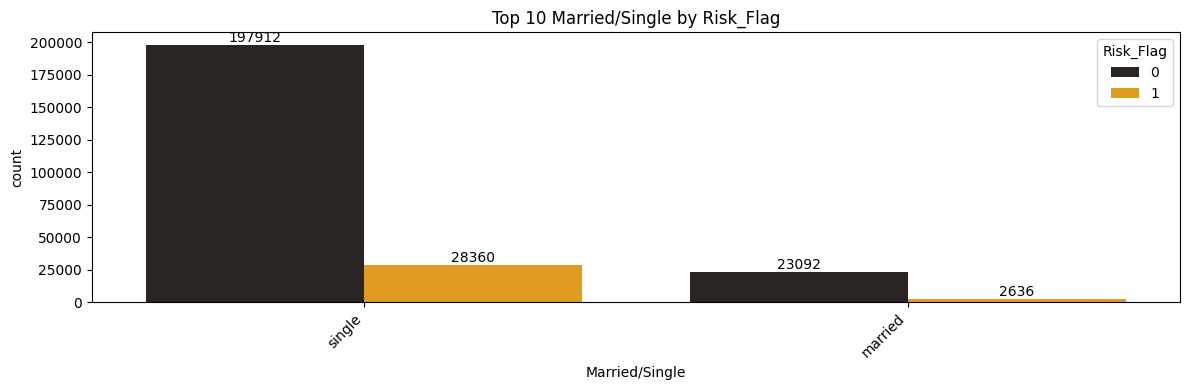

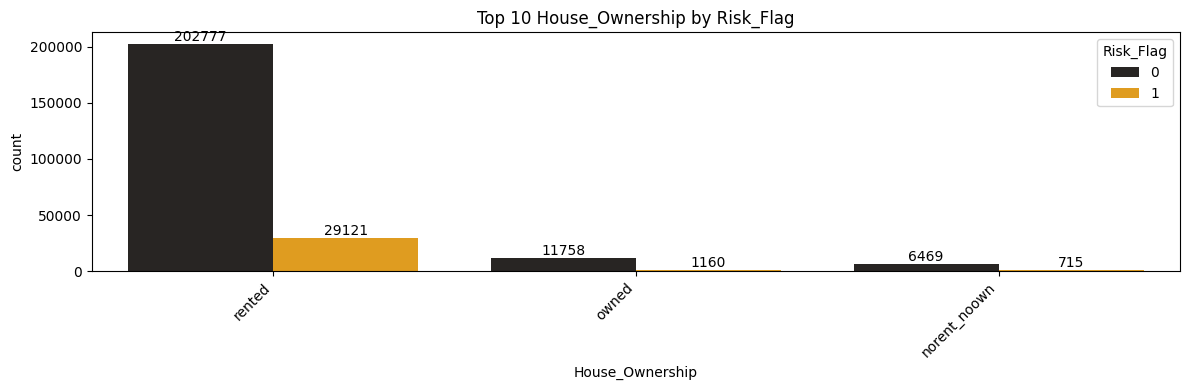

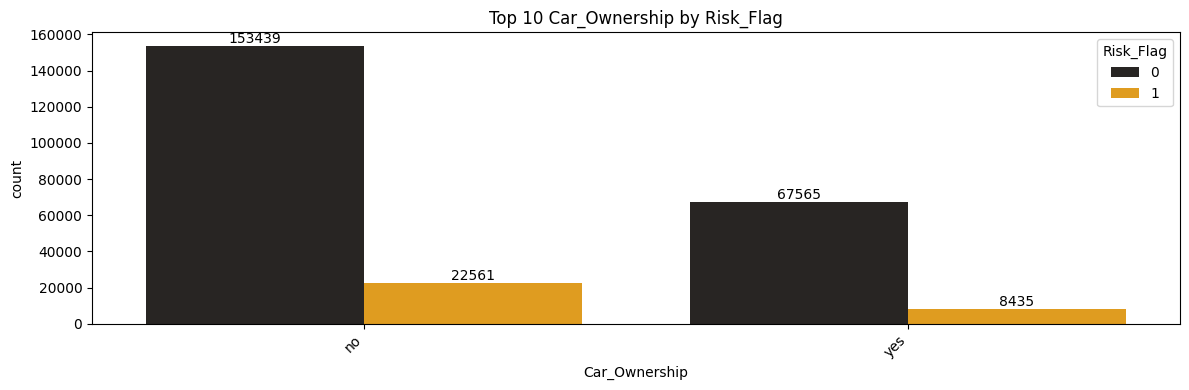

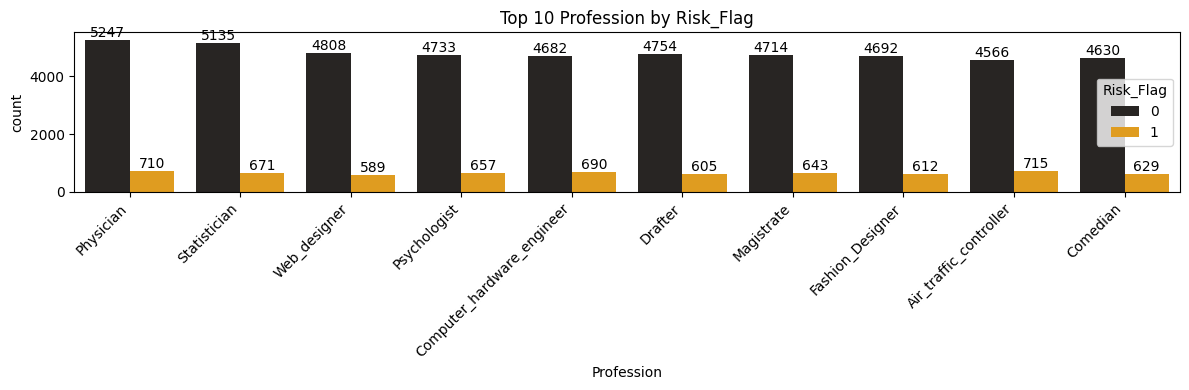

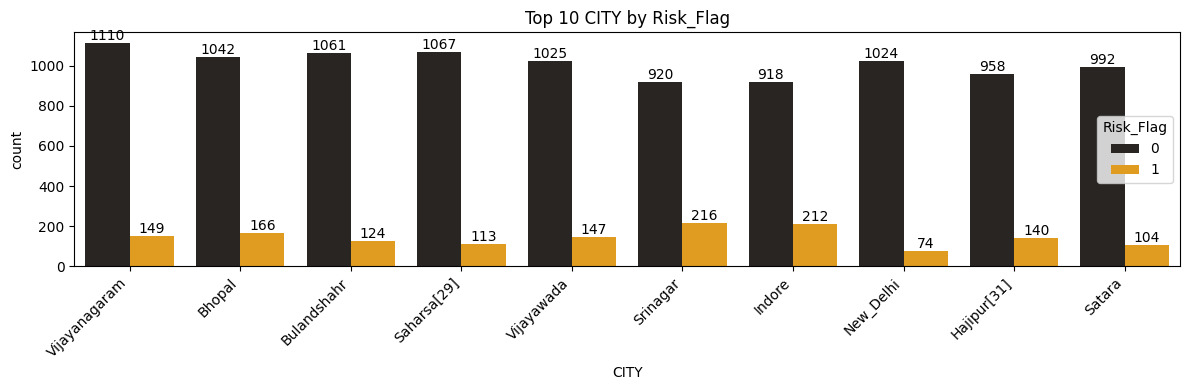

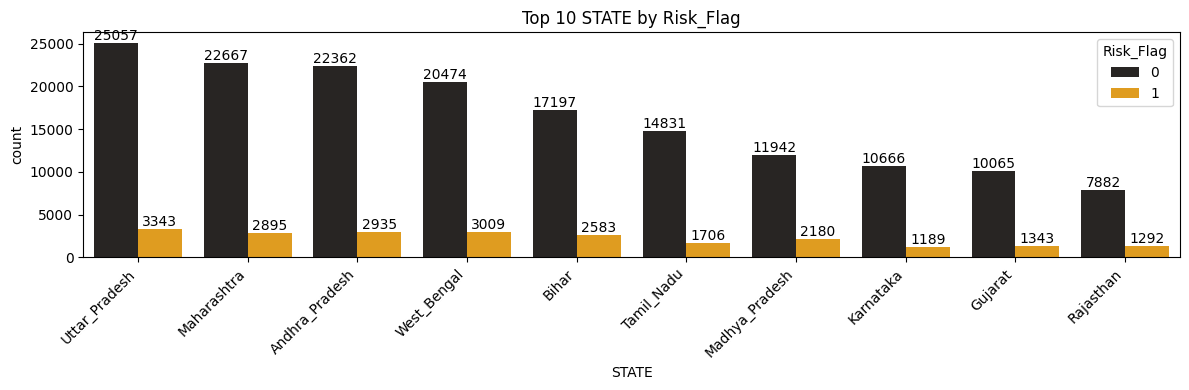

In [20]:
for col in data.select_dtypes(include=['object']).columns:
    top_10 = data[col].value_counts().nlargest(10).index
    subset = data[data[col].isin(top_10)]

    plt.figure(figsize=(12, 4))
    ax = sns.countplot(
        data=subset,
        x=col,
        order=top_10,
        hue='Risk_Flag',
        palette='dark:orange'
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

    plt.title(f"Top 10 {col} by Risk_Flag")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


#### Target column analysis

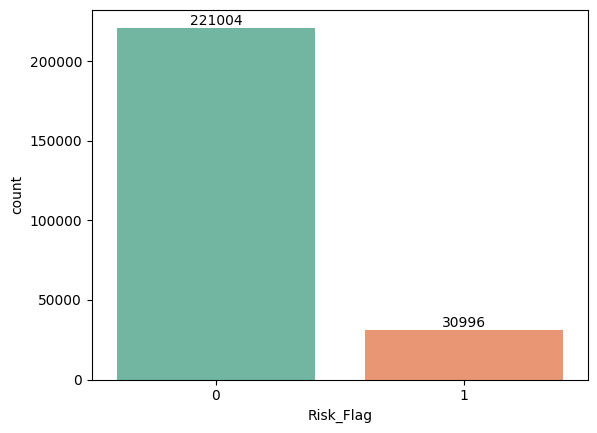

In [21]:
ax = sns.countplot(x=data['Risk_Flag'], palette="Set2")

for i, container in enumerate(ax.containers):
    ax.bar_label(container)
    
plt.show()

In [22]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252000 entries, 0 to 251999
Data columns (total 13 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   Id                 252000 non-null  int64 
 1   Income             252000 non-null  int64 
 2   Age                252000 non-null  int64 
 3   Experience         252000 non-null  int64 
 4   Married/Single     252000 non-null  object
 5   House_Ownership    252000 non-null  object
 6   Car_Ownership      252000 non-null  object
 7   Profession         252000 non-null  object
 8   CITY               252000 non-null  object
 9   STATE              252000 non-null  object
 10  CURRENT_JOB_YRS    252000 non-null  int64 
 11  CURRENT_HOUSE_YRS  252000 non-null  int64 
 12  Risk_Flag          252000 non-null  int64 
dtypes: int64(7), object(6)
memory usage: 25.0+ MB


### EDA Summary

**Data quality**
- `Id` is a row identifier with no predictive signal → drop before modeling.
- No duplicate rows.
- No missing values across any column.

**Distributions**
- Numeric features are reasonably symmetric — no log / sqrt / Box-Cox transformation required (Pearson skew within ±0.3 for all columns).
- IQR-based outlier counts are within acceptable limits → no aggressive capping needed.

**Correlation & multicollinearity**
- No strongly correlated numeric pair (|r| > 0.7).
- All VIF values are well below 5 → no multicollinearity concerns.

**Categorical encoding plan**

| Column | Cardinality | Type | Encoding |
|---|---|---|---|
| `Married/Single` | 2 | Nominal (binary) | One-Hot |
| `Car_Ownership` | 2 | Nominal (binary) | One-Hot |
| `House_Ownership` | 3 | Ordinal (`owned` > `rented` > `norent_noown`) | Ordinal Encoding |
| `STATE` | ~29 | Nominal | Target Encoding (CV-based, to avoid leakage) |
| `Profession` | ~50 | Nominal (high-card) | Target Encoding |
| `CITY` | ~300+ | Nominal (high-card) | Target Encoding |

**Target variable (`Risk_Flag`)**
- Highly **imbalanced** (~88% class 0, ~12% class 1).
- Handling options:
  - Resampling: `SMOTE` or `Oversampling`.


### Data Preprocessing

In [23]:
df = data.copy()

#### Encoding

In [24]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ['Married/Single', 'House_Ownership']

ohe = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

ohe_encoding = ohe.fit_transform(df[cat_cols])

encoded_df = pd.DataFrame(ohe_encoding, columns=ohe.get_feature_names_out(cat_cols))

# Drop original categorical cols & join encoded
df = df.drop(columns=cat_cols).reset_index(drop=True)
df = pd.concat([df, encoded_df], axis=1)

In [25]:
from sklearn.preprocessing import OrdinalEncoder

ownership_order = [['no', 'yes']]

ordinal_encoder = OrdinalEncoder(categories=ownership_order)

df['car_ownership'] = ordinal_encoder.fit_transform(df[['Car_Ownership']])
df.drop(columns=['Car_Ownership'], inplace=True)

In [26]:
from sklearn.preprocessing import TargetEncoder

# High-cardinality categoricals → target encoding
target_cols = ['Profession', 'CITY', 'STATE']

# cv=5 uses out-of-fold encoding on fit_transform to prevent target leakage.
# smooth='auto' shrinks rare-category means toward the global mean.
target_encoder = TargetEncoder(
    target_type='binary',
    cv=5,
    smooth='auto',
    random_state=42,
)

df[target_cols] = target_encoder.fit_transform(df[target_cols], df['Risk_Flag'])


### Model Building

#### Split the dependent and independent feature

In [27]:
X = df.drop(columns=['Risk_Flag'])
y = df['Risk_Flag']

#### Split the train and test data

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)  

#### Balance the target column

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42, sampling_strategy='not majority')

x_train_res, y_train_res = smote.fit_resample(X_train, y_train)


print("Class distribution before SMOTE:\n", y_train.value_counts(normalize=True))
print("Class distribution after SMOTE:\n", pd.Series(y_train_res).value_counts(normalize=True))

Class distribution before SMOTE:
 Risk_Flag
0    0.876999
1    0.123001
Name: proportion, dtype: float64
Class distribution after SMOTE:
 Risk_Flag
0    0.5
1    0.5
Name: proportion, dtype: float64


#### Feature scaling

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(x_train_res),index=x_train_res.index, columns=x_train_res.columns)
X_test_scaled =  pd.DataFrame(scaler.transform(X_test), index=X_test.index, columns=X_test.columns)

#### ML models Generic methods to identify the baseline model

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    ConfusionMatrixDisplay, RocCurveDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier, VotingClassifier
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier


def assess_overfitting(row, cv):
    """Assess relative overfitting risk using train/test F1 and CV scores."""
    train_f1 = row["Train F1"]
    test_f1 = row["Test F1"]

    cv_mean = row[f"CV F1 Mean ({cv}-fold)"]
    cv_std = row[f"CV F1 Std ({cv}-fold)"]

    # Relative gap
    rel_gap = (train_f1 - test_f1) / train_f1

    # Check CV agreement
    cv_agreement = abs(test_f1 - cv_mean) <= cv_std

    if rel_gap > 0.15 and not cv_agreement:
        return "High"
    elif rel_gap > 0.1:
        return "Medium"
    else:
        return "Low"

def plot_roc_curves(model, X_tr, y_tr, X_te, y_te, n_classes, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"{name} - ROC Curves", fontsize=14)

    if n_classes == 2:
        # Binary ROC (normal case)
        RocCurveDisplay.from_estimator(model, X_tr, y_tr, ax=axes[0], name="Train")
        axes[0].set_title("ROC Curve (Train)")

        RocCurveDisplay.from_estimator(model, X_te, y_te, ax=axes[1], name="Test")
        axes[1].set_title("ROC Curve (Test)")

    else:
        # Multiclass OvR ROC
        y_train_bin = label_binarize(y_tr, classes=np.unique(y_tr))
        y_test_bin = label_binarize(y_te, classes=np.unique(y_te))

        y_train_proba = model.predict_proba(X_tr)
        y_test_proba = model.predict_proba(X_te)

        for i, cls in enumerate(np.unique(y_tr)):
            RocCurveDisplay.from_predictions(
                y_train_bin[:, i], y_train_proba[:, i],
                name=f"Class {cls}", ax=axes[0]
            )
        axes[0].set_title("ROC Curve (Train)")

        for i, cls in enumerate(np.unique(y_te)):
            RocCurveDisplay.from_predictions(
                y_test_bin[:, i], y_test_proba[:, i],
                name=f"Class {cls}", ax=axes[1]
            )
        axes[1].set_title("ROC Curve (Test)")

    plt.tight_layout()
    plt.show()


def evaluate_models(X_train, X_test, y_train, y_test,
                    X_scaled_train, X_scaled_test,
                    cv,
                    ranking_metric="Test F1"):
    """
    Evaluate multiple ML models (binary or multiclass) with default hyperparameters.
    Hyperparameter tuning will be performed later on the top-performing model.
    """

    results = []
    feature_names = X_train.columns

    # Models that REQUIRE scaling
    models_scaled = {
        "Logistic Regression": LogisticRegression(max_iter=1000),
        "KNN": KNeighborsClassifier(),
        "SVM": SVC(probability=True),
    }

    # Models that DO NOT require scaling
    models_unscaled = {
        "Decision Tree-Gini": DecisionTreeClassifier(),
        "Decision Tree-Entropy": DecisionTreeClassifier(criterion='entropy'),
        "Random Forest": RandomForestClassifier(),
        "XGBoost": XGBClassifier(eval_metric="logloss"),
        "Naive Bayes": GaussianNB(),
        "Bagging": BaggingClassifier(),
        "AdaBoost": AdaBoostClassifier(),
        "Gradient Boosting": GradientBoostingClassifier(),
    }

    def run_model(name, model, X_tr, X_te, X_full, y_tr, y_te, y_full, feature_names, cv):
        """Train, evaluate, plot confusion matrix & ROC, and extract feature importance."""

        # Train
        model.fit(X_tr, y_tr)

        # Predictions
        y_pred_train = model.predict(X_tr)
        y_pred_test = model.predict(X_te)

        # Multi vs Binary
        n_classes = len(np.unique(y_full))
        average_metric = 'weighted'

        # --- Metrics ---
        metrics = {
            "Algorithm": name,
            "Train Accuracy": accuracy_score(y_tr, y_pred_train),
            "Train Precision": precision_score(y_tr, y_pred_train, average=average_metric),
            "Train Recall": recall_score(y_tr, y_pred_train, average=average_metric),
            "Train F1": f1_score(y_tr, y_pred_train, average=average_metric),
            "Test Accuracy": accuracy_score(y_te, y_pred_test),
            "Test Precision": precision_score(y_te, y_pred_test, average=average_metric),
            "Test Recall": recall_score(y_te, y_pred_test, average=average_metric),
            "Test F1": f1_score(y_te, y_pred_test, average=average_metric),
        }

        # ROC-AUC
        plot_roc_curves(model, X_tr, y_tr, X_te, y_te, n_classes, name)

        # CV
        cv_scores = cross_val_score(model, X_tr, y_tr, cv=cv, scoring="f1_weighted")
        metrics[f"CV F1 Mean ({cv}-fold)"] = cv_scores.mean()
        metrics[f"CV F1 Std ({cv}-fold)"] = cv_scores.std()

        results.append(metrics)

        # Confusion Matrix
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        fig.suptitle(f"{name} - Confusion Matrices", fontsize=14)
        ConfusionMatrixDisplay.from_estimator(model, X_tr, y_tr, ax=axes[0], cmap="Blues", colorbar=False)
        axes[0].set_title("Train")
        ConfusionMatrixDisplay.from_estimator(model, X_te, y_te, ax=axes[1], cmap="Oranges_r", colorbar=False)
        axes[1].set_title("Test")
        plt.tight_layout()
        plt.show()

        # ROC Curves
        if hasattr(model, "predict_proba"):
            try:
                if n_classes == 2:
                    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                    fig.suptitle(f"{name} - ROC Curves", fontsize=14)
                    RocCurveDisplay.from_estimator(model, X_tr, y_tr, ax=axes[0], name="Train")
                    axes[0].set_title("ROC Curve (Train)")
                    RocCurveDisplay.from_estimator(model, X_te, y_te, ax=axes[1], name="Test")
                    axes[1].set_title("ROC Curve (Test)")
                    plt.tight_layout()
                    plt.show()
            except Exception as e:
                print(f"ROC curve skipped for {name}: {e}")

        # Feature Importances
        try:
            if hasattr(model, "coef_"):
                coefs = pd.Series(model.coef_[0], index=feature_names)
                top_features = coefs.sort_values(ascending=False).head(10)
                print(f"\nTop features for {name} (coefficients):\n", top_features)
                top_features.plot(kind="bar", figsize=(8, 4), title=f"Top Features - {name}")
                plt.show()
            elif hasattr(model, "feature_importances_"):
                importances = pd.Series(model.feature_importances_, index=feature_names)
                top_features = importances.sort_values(ascending=False).head(10)
                print(f"\nTop features for {name} (feature_importances_):\n", top_features)
                top_features.plot(kind="bar", figsize=(8, 4), title=f"Top Features - {name}")
                plt.show()
            else:
                print(f"Feature importance not available for {name}(no coef_ or feature_importances_ attribute)")
        except Exception as e:
            print(f"Could not extract feature importance for {name} → {e}")

    # Run scaled
    for name, model in models_scaled.items():
        print(f"************ Started {name} ************")
        run_model(name, model,
                  X_scaled_train, X_scaled_test, pd.concat([X_scaled_train, X_scaled_test]),
                  y_train, y_test, pd.concat([y_train, y_test]),
                  feature_names, cv)
        print("*" * 100)

    # Run unscaled
    for name, model in models_unscaled.items():
        print(f"************ Started {name} ************")
        run_model(name, model,
                  X_train, X_test, pd.concat([X_train, X_test]),
                  y_train, y_test, pd.concat([y_train, y_test]),
                  feature_names, cv)
        print("*" * 100)

    # Stacking
    stacking_clf = StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000)),
            ("rf", RandomForestClassifier()),
            ("xgb", XGBClassifier(eval_metric="logloss")),
        ],
        final_estimator=LogisticRegression()
    )
    run_model("Stacking", stacking_clf,
              X_train, X_test, pd.concat([X_train, X_test]),
              y_train, y_test, pd.concat([y_train, y_test]),
              feature_names, cv)

    # Voting
    voting_clf = VotingClassifier(
        estimators=[
            ("lr", LogisticRegression(max_iter=1000)),
            ("rf", RandomForestClassifier()),
            ("xgb", XGBClassifier(eval_metric="logloss")),
        ],
        voting='soft'
    )
    run_model("Voting", voting_clf,
              X_train, X_test, pd.concat([X_train, X_test]),
              y_train, y_test, pd.concat([y_train, y_test]),
              feature_names, cv)

    # Leaderboard
    leaderboard = pd.DataFrame(results)
    leaderboard["Overfitting Risk"] = leaderboard.apply(lambda row: assess_overfitting(row, cv), axis=1)
    leaderboard = leaderboard.sort_values(by=ranking_metric, ascending=False).reset_index(drop=True)

    return leaderboard


************ Started Logistic Regression ************


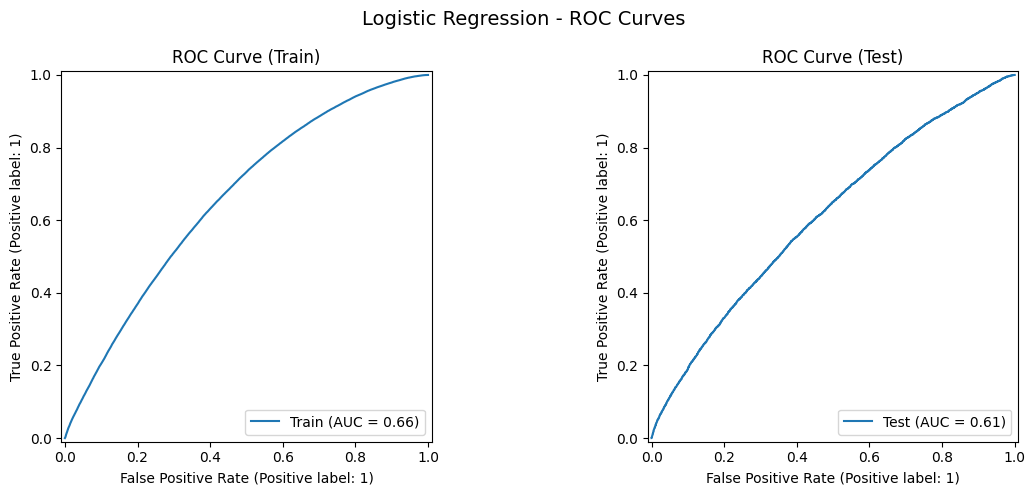

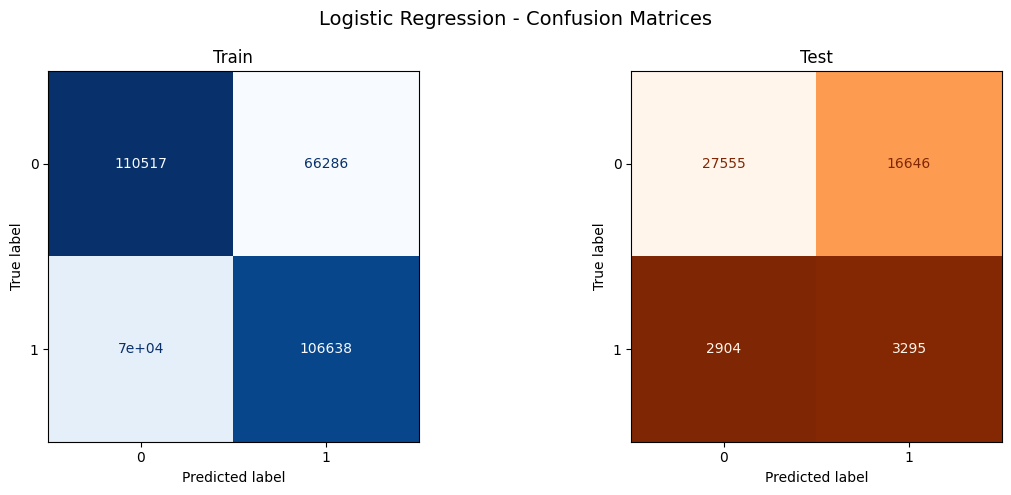

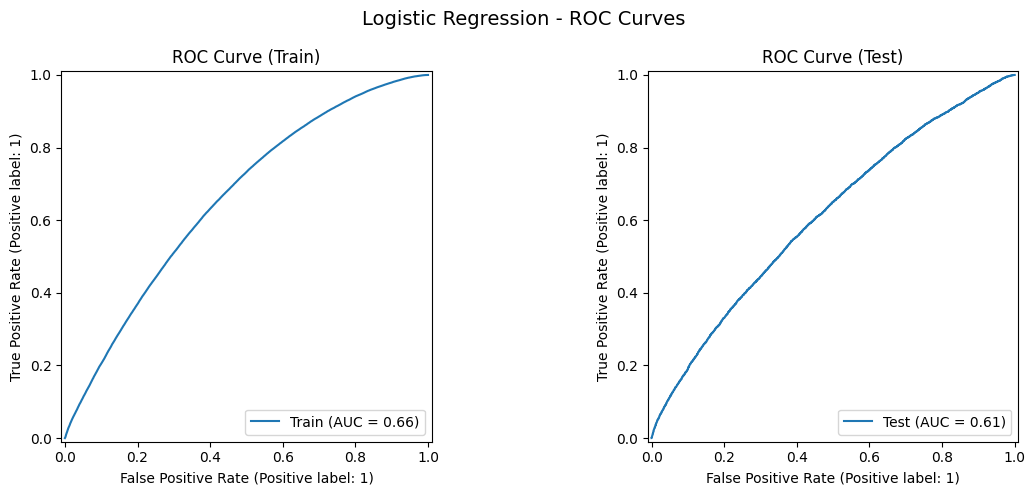


Top features for Logistic Regression (coefficients):
 CITY                      0.443476
Profession                0.132489
Id                        0.128015
House_Ownership_rented    0.081667
Married/Single_single     0.072209
STATE                     0.007143
House_Ownership_owned    -0.014536
Income                   -0.020938
CURRENT_JOB_YRS          -0.057267
car_ownership            -0.079830
dtype: float64


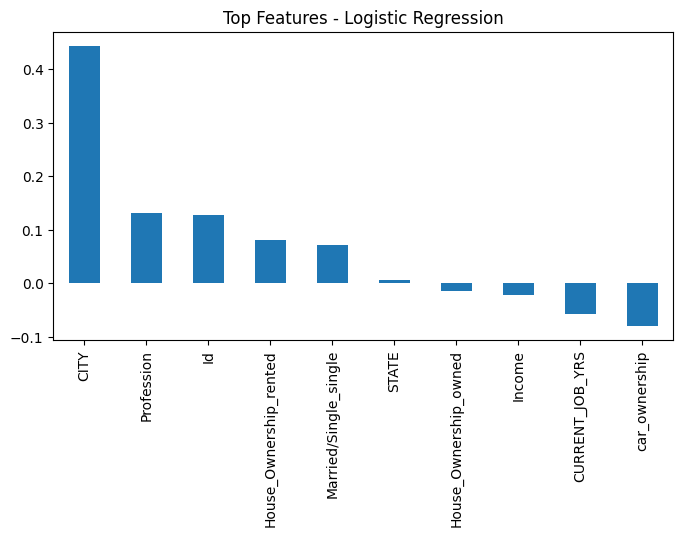

****************************************************************************************************
************ Started KNN ************


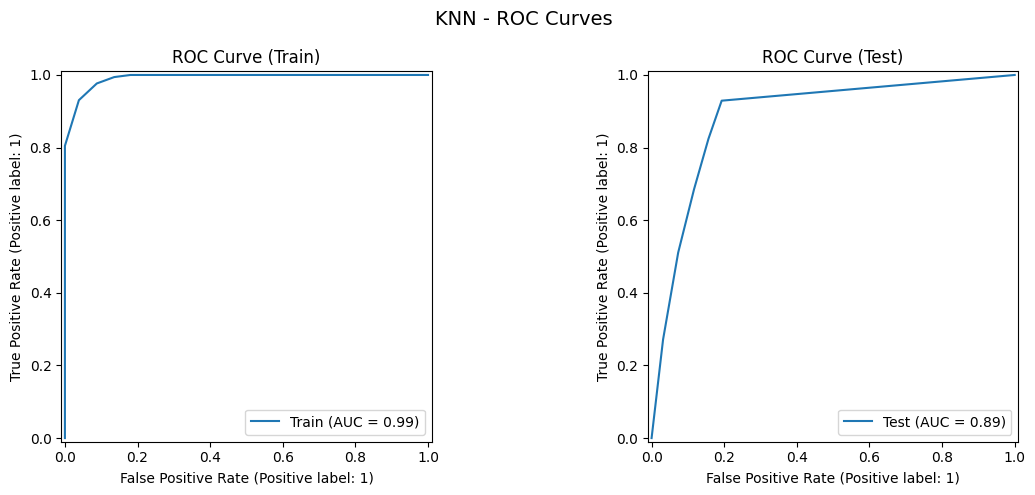

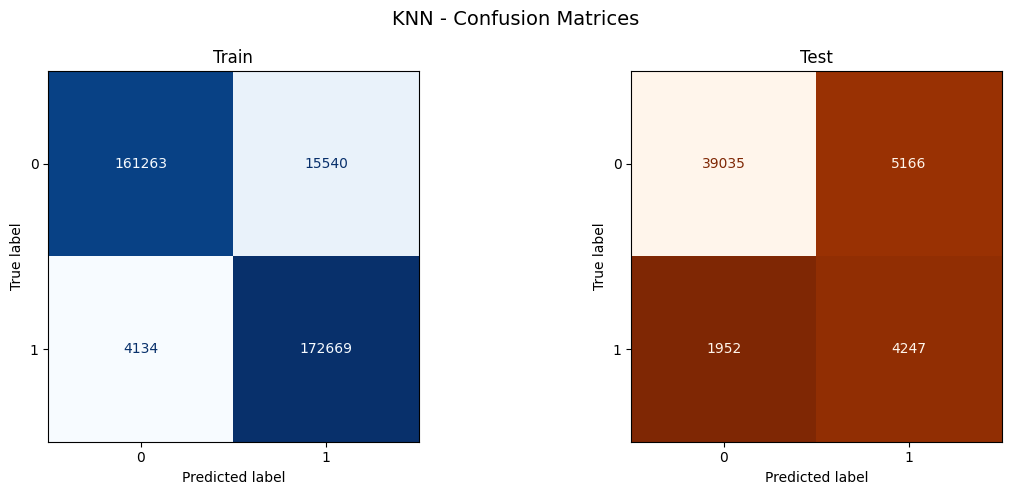

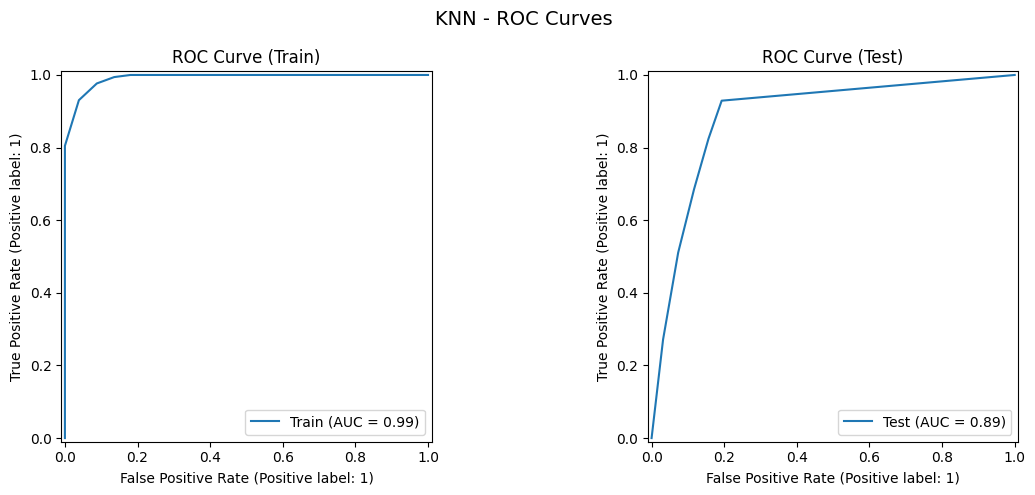

Feature importance not available for KNN(no coef_ or feature_importances_ attribute)
****************************************************************************************************
************ Started SVM ************


In [ ]:
model_eval = evaluate_models(
    x_train_res, X_test, y_train_res, y_test,
    X_train_scaled, X_test_scaled,
    10
)
display(model_eval)
